In [10]:
import pickle
# To load the dictionary back
with open("llama_11b_800_predictions.pkl", "rb") as f:
    predictions = pickle.load(f)

In [1]:
cd Downloads/

/Users/akashawasthi/Downloads


In [ ]:
import numpy as np
import json




import json

# Path to your JSON file
file_path = "original_fixation_transcript_label_missed.json"

# Step 1: Open and load the JSON file
with open(file_path, 'r') as file:
    datalab = json.load(file)

# Step 2: Display the entire JSON content
#print("JSON Data:", datalab)


import json

# Path to your JSON file
file_path = "original_fixation_transcript_simulated_error_data.json"

# Step 1: Open and load the JSON file
with open(file_path, 'r') as file:
    data = json.load(file)

# Step 2: Display the entire JSON content
#print("JSON Data:", data)

import random
data = {key: data[key] for key in random.sample(data.keys(), len(data))}





















def euclidean_distance(point1, point2):
    """Calculate the Euclidean distance between two points."""
    return np.sqrt((point1[0] - point2[0]) ** 2 + (point1[1] - point2[1]) ** 2)

def find_closest_times(fixation_data, begin_time, end_time):
    """Find the closest fixation times to the begin and end times of the phrase."""
    closest_begin_time = max([fix['Time (in secs)'] for fix in fixation_data if fix['Time (in secs)'] <= begin_time], default=None)
    closest_end_time = min([fix['Time (in secs)'] for fix in fixation_data if fix['Time (in secs)'] >= end_time], default=None)
    return closest_begin_time, closest_end_time

def create_subgraph(sentence_text, fixation_nodes, sentence_counter):
    """Creates a subgraph for a given set of fixation nodes, including revisit edges."""
    subgraph = {
        "Abnormality": sentence_text,
        "nodes": fixation_nodes,
        "edges": []
    }
    
    # Dictionary to track nodes by their positions for revisits
    position_tracker = {}

    # Create edges based on Euclidean distance and check for revisits
    for i, current_node in enumerate(fixation_nodes):
        # Track revisits: Check if position was already seen
        position_key = tuple(current_node["fixation_point"])
        if position_key in position_tracker:
            original_node = position_tracker[position_key]
            # Add a revisit edge from the original node to the current revisited node
            subgraph["edges"].append({
                "from": original_node["id"],
                "to": current_node["id"],
                "type": "revisit"
            })
            #print(f"Revisit detected: Edge added from {original_node['id']} to {current_node['id']}.")
        else:
            # If it's a new position, add it to the tracker
            position_tracker[position_key] = current_node

        # Create sequential edges based on Euclidean distance for immediate neighbors
        if i > 0:
            previous_node = fixation_nodes[i - 1]
            dist = euclidean_distance(previous_node["fixation_point"], current_node["fixation_point"])
            subgraph["edges"].append({
                "from": previous_node["id"],
                "to": current_node["id"],
                "distance": round(dist, 3)
            })
    
    # Debugging output
    #if fixation_nodes:
      #  print(f"Subgraph for '{sentence_text}' has {len(fixation_nodes)} nodes and {len(subgraph['edges'])} edges.")
    #else:
       # print(f"No nodes added to subgraph for '{sentence_text}'.")

    return subgraph

def create_scene_graph_by_sentence(timestamped_report, fixation_data):
    """Construct a scene graph with each sentence as a phrase and idle fixations as a separate subgraph."""
    scene_graph = {
        "scene_graph": {
            "subgraphs": [],
            "inter_phrase_edges": []
        }
    }

    sentence_counter = 1  # Unique ID base for each sentence
    phrase_time_ranges = []  # List to store phrase time ranges for idle fixation exclusion
    idle_fixations = []  # List to collect fixations with no phrase association

    # Process each sentence in the report
    for sentence_info in timestamped_report:
        sentence_text = sentence_info['sentence']
        begin_time, end_time = sentence_info['begin_time'], sentence_info['end_time']
        phrase_time_ranges.append((begin_time, end_time))  # Record time range for this phrase
        
        # Get the closest begin and end fixation times
        closest_begin_time, closest_end_time = find_closest_times(fixation_data, begin_time, end_time)
        if closest_begin_time is None or closest_end_time is None:
            #print(f"No fixations found within bounds for '{sentence_text}'")
            continue

        # Collect fixation points within this phrase's time range
        fixation_nodes = []
        for fixation in fixation_data:
            fixation_time = fixation['Time (in secs)']
            if closest_begin_time <= fixation_time <= closest_end_time:
                fpx, fpy, fpd = fixation['FPOGX'], fixation['FPOGY'], fixation['FPOGD']
                node_id = f"fixation_{sentence_counter * 10 + len(fixation_nodes)}"  # Unique node ID
                fixation_nodes.append({
                    "id": node_id,
                    "fixation_point": [fpx, fpy],
                    "fixation_duration": fpd
                })

        # Create and add subgraph for the phrase, including revisits
        subgraph = create_subgraph(sentence_text, fixation_nodes, sentence_counter)
        scene_graph["scene_graph"]["subgraphs"].append(subgraph)

        # Connect to previous sentence if applicable
        if len(scene_graph["scene_graph"]["subgraphs"]) > 1:
            previous_phrase = scene_graph["scene_graph"]["subgraphs"][-2]["Abnormality"]
            scene_graph["scene_graph"]["inter_phrase_edges"].append({
                "from": previous_phrase,
                "to": sentence_text,
                "relationship": "sequence"
            })

        sentence_counter += 1  # Increment for unique node IDs

    # Collect idle fixations (not within any phrase's time bounds)
    for fixation in fixation_data:
        fixation_time = fixation['Time (in secs)']
        if not any(begin <= fixation_time <= end for begin, end in phrase_time_ranges):
            node_id = f"idle_fixation_{len(idle_fixations)}"
            idle_fixations.append({
                "id": node_id,
                "fixation_point": [fixation['FPOGX'], fixation['FPOGY']],
                "fixation_duration": fixation['FPOGD']
            })

    # Create and add idle subgraph
    idle_subgraph = create_subgraph("Idle Subgraph", idle_fixations, 0)
    scene_graph["scene_graph"]["subgraphs"].append(idle_subgraph)

    return scene_graph


In [3]:
#preds=resultf.copy()
def transform_label_dict(label_dict):
    # Define the mapping between class labels and the corresponding descriptions
    label_mapping = {
        'class_label_1': 'Missing Subgraph due to Missing fixation',
        'class_label_2': 'Missing Subgraph due to reduced fixation duration',
        'class_label_3': 'Missing Subgraph due to undefined reason'
    }

    transformed_dict = {}

    for key, value in label_dict.items():
        transformed_dict[key] = {}

        # Map each label to its new description based on `label_mapping`
        for class_label, new_description in label_mapping.items():
            transformed_dict[key][new_description] = value.get(class_label, 0)

        # Set "No missing abnormality" based on all class labels being 0
        transformed_dict[key]['No Missing Subgraph'] = int(all(
            value.get(class_label, 0) == 0 for class_label in label_mapping
        ))

    return transformed_dict



# Transform the dictionary and print the result
new_label_dict = transform_label_dict(datalab)
print("Transformed Label Dictionary:", new_label_dict)


Transformed Label Dictionary: {'002da0d9-ce49c30d-4dfcc1f8-746d2401-d8044d48': {'Missing Subgraph due to Missing fixation': 0, 'Missing Subgraph due to reduced fixation duration': 0, 'Missing Subgraph due to undefined reason': 0, 'No Missing Subgraph': 1}, '0066734a-35568fde-fd52ba23-ec66f3de-88d4aaf9': {'Missing Subgraph due to Missing fixation': 0, 'Missing Subgraph due to reduced fixation duration': 0, 'Missing Subgraph due to undefined reason': 0, 'No Missing Subgraph': 1}, '00fe73b4-5215bb4f-94bbccc4-ac5f4f6f-52805cfb': {'Missing Subgraph due to Missing fixation': 0, 'Missing Subgraph due to reduced fixation duration': 0, 'Missing Subgraph due to undefined reason': 0, 'No Missing Subgraph': 1}, '010fa20c-6ac04c8a-f6d4bc0b-eb1e735c-cd940793': {'Missing Subgraph due to Missing fixation': 0, 'Missing Subgraph due to reduced fixation duration': 0, 'Missing Subgraph due to undefined reason': 0, 'No Missing Subgraph': 1}, '018680d4-8fb864f0-dffebf54-bcba02ab-9b601e7a': {'Missing Subgrap

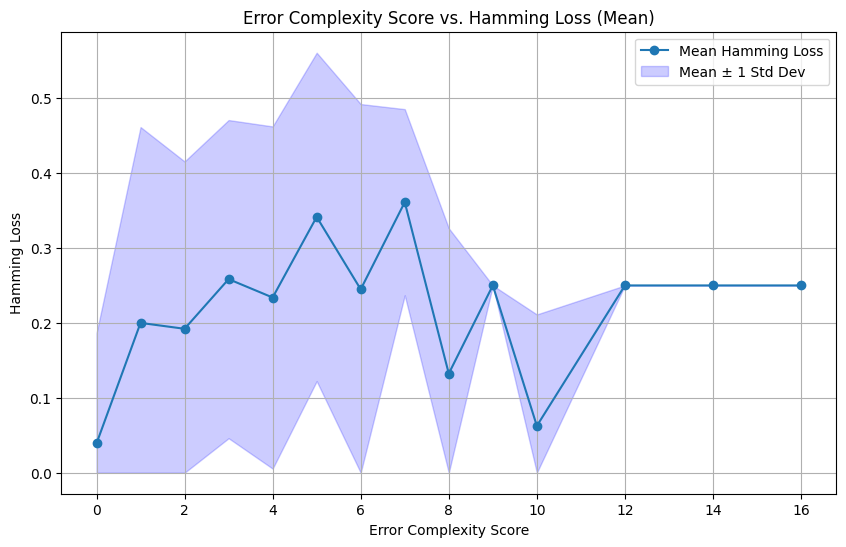

In [ ]:


import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import hamming_loss
import numpy as np
import json
import random
from collections import defaultdict

# Load label metadata
with open("original_fixation_transcript_label_missed.json", 'r') as file:
    datalab = json.load(file)

# Load fixation data
with open("original_fixation_transcript_simulated_error_data.json", 'r') as file:
    data = json.load(file)

# Shuffle data for randomness
data = {key: data[key] for key in random.sample(data.keys(), len(data))}

# Load predictions
#with open("multi_agent_miccai_withno_inexp_subgraph_subdidvision_data1.pkl", "rb") as f:
    #loaded_data = pickle.load(f)
loaded_data=predictions
# Function to count subgraphs
def count_subgraphs(scene_graph):
    return len(scene_graph['scene_graph']['subgraphs'])

# Function to extract binary values for classification
def extract_binary_values(label_dict, sample_id):
    if sample_id not in label_dict:
        return [0, 0, 0, 0]  # Default values
    sample_labels = label_dict[sample_id]
    return [
        sample_labels['Missing Subgraph due to Missing fixation'],
        sample_labels['Missing Subgraph due to reduced fixation duration'],
        sample_labels['Missing Subgraph due to undefined reason'],
        sample_labels['No Missing Subgraph']
    ]

# Dictionary to store Hamming Loss grouped by complexity score
hamming_loss_by_complexity = defaultdict(list)

# Iterate through data
for sample_id, sample_data in data.items():
    if sample_id not in loaded_data or sample_id not in datalab:
        continue  # Skip if data is missing

    # Scene graph for experienced radiologist
    exp_fix = sample_data['correct_data']
    scene_graph_exp = create_scene_graph_by_sentence(exp_fix['transcript'], [
        {'FPOGX': exp_fix['X_ORIGINAL'][i], 'FPOGY': exp_fix['Y_ORIGINAL'][i], 
         'FPOGD': exp_fix['FPOGD'][i], 'Time (in secs)': exp_fix['Time (in secs)'][i]} 
        for i in range(len(exp_fix['X_ORIGINAL']))
    ])

    # Scene graph for inexperienced radiologist
    inexp_fix = sample_data['incorrect_data'] if sample_data['incorrect_data'] else sample_data['correct_data']
    scene_graph_inexp = create_scene_graph_by_sentence(inexp_fix['transcript'], [
        {'FPOGX': inexp_fix['X_ORIGINAL'][i], 'FPOGY': inexp_fix['Y_ORIGINAL'][i], 
         'FPOGD': inexp_fix['FPOGD'][i], 'Time (in secs)': inexp_fix['Time (in secs)'][i]} 
        for i in range(len(inexp_fix['X_ORIGINAL']))
    ])

    # Compute subgraph difference and complexity score
    num_subgraphs_exp = count_subgraphs(scene_graph_exp)
    num_subgraphs_inexp = count_subgraphs(scene_graph_inexp)
    error_complexity_score = abs(num_subgraphs_exp - num_subgraphs_inexp) * num_subgraphs_inexp

    # Extract labels
    predicted_labels = predictions  # Replace with actual predictions
    actual_labels = new_label_dict # Replace with ground truth

    # Extract binary values for predicted and actual labels
    predicted_values = extract_binary_values(predicted_labels, sample_id)
    actual_values = extract_binary_values(actual_labels, sample_id)

    # Calculate Hamming Loss for the sample
    sample_hamming_loss = hamming_loss([actual_values], [predicted_values])
    
    # Store Hamming Loss
    hamming_loss_by_complexity[error_complexity_score].append(sample_hamming_loss)

# Compute mean and standard deviation of Hamming Loss for each complexity score
complexity_scores = sorted(hamming_loss_by_complexity.keys())
mean_hamming_loss = [np.mean(hamming_loss_by_complexity[score]) for score in complexity_scores]
std_hamming_loss = [np.std(hamming_loss_by_complexity[score]) for score in complexity_scores]  # Compute standard deviation

# Plot mean Hamming Loss with confidence interval
# Plot mean Hamming Loss with confidence interval
plt.figure(figsize=(10, 6))
plt.plot(complexity_scores, mean_hamming_loss, label="Mean Hamming Loss", marker='o', linestyle='-')

# Clip the lower bound of the confidence interval to 0 to avoid negative values
lower_bound = np.array(mean_hamming_loss) - np.array(std_hamming_loss)
upper_bound = np.array(mean_hamming_loss) + np.array(std_hamming_loss)

# Ensure that the lower bound doesn't go below 0
lower_bound = np.maximum(lower_bound, 0)

# Plot the confidence interval
plt.fill_between(complexity_scores, lower_bound, upper_bound, color='blue', alpha=0.2,
                 label="Mean ± 1 Std Dev")  # Shaded region for variability

# Labels and formatting
plt.xlabel("Error Complexity Score")
plt.ylabel("Hamming Loss")
plt.title("Error Complexity Score vs. Hamming Loss (Mean)")
plt.legend()
plt.grid(True)
plt.show()



In [15]:
import pickle
# To load the dictionary back
with open("data_maarta_final_1025_pred.pkl", "rb") as f:
    predictions = pickle.load(f)

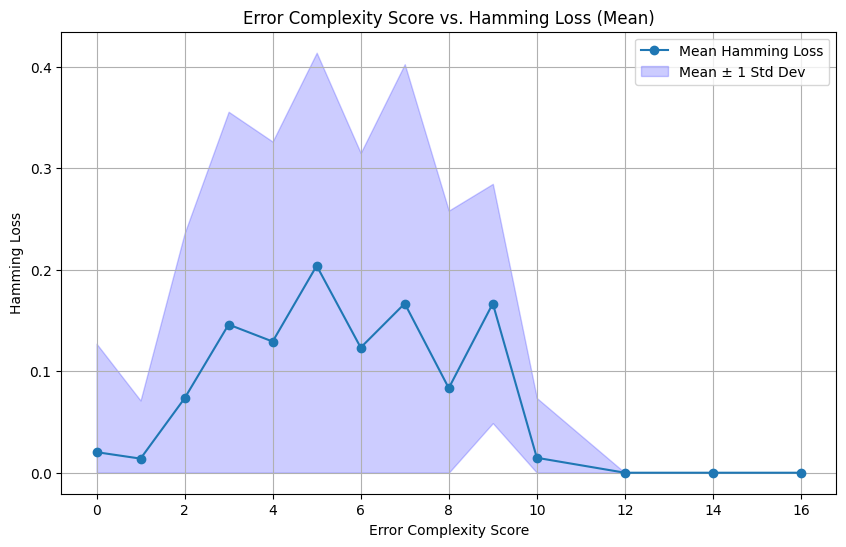

In [ ]:

import pickle
# To load the dictionary back
with open("llama_11b_800_predictions.pkl", "rb") as f:
    predictions = pickle.load(f)



import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import hamming_loss
import numpy as np
import json
import random
from collections import defaultdict

# Load label metadata
with open("original_fixation_transcript_label_missed.json", 'r') as file:
    datalab = json.load(file)

# Load fixation data
with open("original_fixation_transcript_simulated_error_data.json", 'r') as file:
    data = json.load(file)

# Shuffle data for randomness
data = {key: data[key] for key in random.sample(data.keys(), len(data))}

# Load predictions
#with open("multi_agent_miccai_withno_inexp_subgraph_subdidvision_data1.pkl", "rb") as f:
    #loaded_data = pickle.load(f)
loaded_data=predictions
# Function to count subgraphs
def count_subgraphs(scene_graph):
    return len(scene_graph['scene_graph']['subgraphs'])

# Function to extract binary values for classification
def extract_binary_values(label_dict, sample_id):
    if sample_id not in label_dict:
        return [0, 0, 0, 0]  # Default values
    sample_labels = label_dict[sample_id]
    return [
        sample_labels['Missing Subgraph due to Missing fixation'],
        sample_labels['Missing Subgraph due to reduced fixation duration'],
        sample_labels['Missing Subgraph due to undefined reason'],
        sample_labels['No Missing Subgraph']
    ]

# Dictionary to store Hamming Loss grouped by complexity score
hamming_loss_by_complexity = defaultdict(list)

# Iterate through data
for sample_id, sample_data in data.items():
    if sample_id not in loaded_data or sample_id not in datalab:
        continue  # Skip if data is missing

    # Scene graph for experienced radiologist
    exp_fix = sample_data['correct_data']
    scene_graph_exp = create_scene_graph_by_sentence(exp_fix['transcript'], [
        {'FPOGX': exp_fix['X_ORIGINAL'][i], 'FPOGY': exp_fix['Y_ORIGINAL'][i], 
         'FPOGD': exp_fix['FPOGD'][i], 'Time (in secs)': exp_fix['Time (in secs)'][i]} 
        for i in range(len(exp_fix['X_ORIGINAL']))
    ])

    # Scene graph for inexperienced radiologist
    inexp_fix = sample_data['incorrect_data'] if sample_data['incorrect_data'] else sample_data['correct_data']
    scene_graph_inexp = create_scene_graph_by_sentence(inexp_fix['transcript'], [
        {'FPOGX': inexp_fix['X_ORIGINAL'][i], 'FPOGY': inexp_fix['Y_ORIGINAL'][i], 
         'FPOGD': inexp_fix['FPOGD'][i], 'Time (in secs)': inexp_fix['Time (in secs)'][i]} 
        for i in range(len(inexp_fix['X_ORIGINAL']))
    ])

    # Compute subgraph difference and complexity score
    num_subgraphs_exp = count_subgraphs(scene_graph_exp)
    num_subgraphs_inexp = count_subgraphs(scene_graph_inexp)
    error_complexity_score = abs(num_subgraphs_exp - num_subgraphs_inexp) * num_subgraphs_inexp

    # Extract labels
    predicted_labels = predictions  # Replace with actual predictions
    actual_labels = new_label_dict # Replace with ground truth

    # Extract binary values for predicted and actual labels
    predicted_values = extract_binary_values(predicted_labels, sample_id)
    actual_values = extract_binary_values(actual_labels, sample_id)

    # Calculate Hamming Loss for the sample
    sample_hamming_loss = hamming_loss([actual_values], [predicted_values])
    
    # Store Hamming Loss
    hamming_loss_by_complexity[error_complexity_score].append(sample_hamming_loss)

# Compute mean and standard deviation of Hamming Loss for each complexity score
complexity_scores = sorted(hamming_loss_by_complexity.keys())
mean_hamming_loss = [np.mean(hamming_loss_by_complexity[score]) for score in complexity_scores]
std_hamming_loss = [np.std(hamming_loss_by_complexity[score]) for score in complexity_scores]  # Compute standard deviation

# Plot mean Hamming Loss with confidence interval
# Plot mean Hamming Loss with confidence interval
plt.figure(figsize=(10, 6))
plt.plot(complexity_scores, mean_hamming_loss, label="Mean Hamming Loss", marker='o', linestyle='-')

# Clip the lower bound of the confidence interval to 0 to avoid negative values
lower_bound = np.array(mean_hamming_loss) - np.array(std_hamming_loss)
upper_bound = np.array(mean_hamming_loss) + np.array(std_hamming_loss)

# Ensure that the lower bound doesn't go below 0
lower_bound = np.maximum(lower_bound, 0)

# Plot the confidence interval
plt.fill_between(complexity_scores, lower_bound, upper_bound, color='blue', alpha=0.2,
                 label="Mean ± 1 Std Dev")  # Shaded region for variability

# Labels and formatting
plt.xlabel("Error Complexity Score")
plt.ylabel("Hamming Loss")
plt.title("Error Complexity Score vs. Hamming Loss (Mean)")
plt.legend()
plt.grid(True)
plt.show()



import pickle
# To load the dictionary back
with open("data_maarta_final_1025_pred.pkl", "rb") as f:
    predictions = pickle.load(f)

import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import hamming_loss
import numpy as np
import json
import random
from collections import defaultdict

# Load label metadata
with open("original_fixation_transcript_label_missed.json", 'r') as file:
    datalab = json.load(file)

# Load fixation data
with open("original_fixation_transcript_simulated_error_data.json", 'r') as file:
    data = json.load(file)

# Shuffle data for randomness
data = {key: data[key] for key in random.sample(data.keys(), len(data))}

# Load predictions
#with open("multi_agent_miccai_withno_inexp_subgraph_subdidvision_data1.pkl", "rb") as f:
    #loaded_data = pickle.load(f)
loaded_data=predictions
# Function to count subgraphs
def count_subgraphs(scene_graph):
    return len(scene_graph['scene_graph']['subgraphs'])

# Function to extract binary values for classification
def extract_binary_values(label_dict, sample_id):
    if sample_id not in label_dict:
        return [0, 0, 0, 0]  # Default values
    sample_labels = label_dict[sample_id]
    return [
        sample_labels['Missing Subgraph due to Missing fixation'],
        sample_labels['Missing Subgraph due to reduced fixation duration'],
        sample_labels['Missing Subgraph due to undefined reason'],
        sample_labels['No Missing Subgraph']
    ]

# Dictionary to store Hamming Loss grouped by complexity score
hamming_loss_by_complexity = defaultdict(list)

# Iterate through data
for sample_id, sample_data in data.items():
    if sample_id not in loaded_data or sample_id not in datalab:
        continue  # Skip if data is missing

    # Scene graph for experienced radiologist
    exp_fix = sample_data['correct_data']
    scene_graph_exp = create_scene_graph_by_sentence(exp_fix['transcript'], [
        {'FPOGX': exp_fix['X_ORIGINAL'][i], 'FPOGY': exp_fix['Y_ORIGINAL'][i], 
         'FPOGD': exp_fix['FPOGD'][i], 'Time (in secs)': exp_fix['Time (in secs)'][i]} 
        for i in range(len(exp_fix['X_ORIGINAL']))
    ])

    # Scene graph for inexperienced radiologist
    inexp_fix = sample_data['incorrect_data'] if sample_data['incorrect_data'] else sample_data['correct_data']
    scene_graph_inexp = create_scene_graph_by_sentence(inexp_fix['transcript'], [
        {'FPOGX': inexp_fix['X_ORIGINAL'][i], 'FPOGY': inexp_fix['Y_ORIGINAL'][i], 
         'FPOGD': inexp_fix['FPOGD'][i], 'Time (in secs)': inexp_fix['Time (in secs)'][i]} 
        for i in range(len(inexp_fix['X_ORIGINAL']))
    ])

    # Compute subgraph difference and complexity score
    num_subgraphs_exp = count_subgraphs(scene_graph_exp)
    num_subgraphs_inexp = count_subgraphs(scene_graph_inexp)
    error_complexity_score = abs(num_subgraphs_exp - num_subgraphs_inexp) * num_subgraphs_inexp

    # Extract labels
    predicted_labels = predictions  # Replace with actual predictions
    actual_labels = new_label_dict # Replace with ground truth

    # Extract binary values for predicted and actual labels
    predicted_values = extract_binary_values(predicted_labels, sample_id)
    actual_values = extract_binary_values(actual_labels, sample_id)

    # Calculate Hamming Loss for the sample
    sample_hamming_loss = hamming_loss([actual_values], [predicted_values])
    
    # Store Hamming Loss
    hamming_loss_by_complexity[error_complexity_score].append(sample_hamming_loss)

# Compute mean and standard deviation of Hamming Loss for each complexity score
complexity_scores = sorted(hamming_loss_by_complexity.keys())
mean_hamming_loss = [np.mean(hamming_loss_by_complexity[score]) for score in complexity_scores]
std_hamming_loss = [np.std(hamming_loss_by_complexity[score]) for score in complexity_scores]  # Compute standard deviation

# Plot mean Hamming Loss with confidence interval
# Plot mean Hamming Loss with confidence interval
plt.figure(figsize=(10, 6))
plt.plot(complexity_scores, mean_hamming_loss, label="Mean Hamming Loss", marker='o', linestyle='-')

# Clip the lower bound of the confidence interval to 0 to avoid negative values
lower_bound = np.array(mean_hamming_loss) - np.array(std_hamming_loss)
upper_bound = np.array(mean_hamming_loss) + np.array(std_hamming_loss)

# Ensure that the lower bound doesn't go below 0
lower_bound = np.maximum(lower_bound, 0)

# Plot the confidence interval
plt.fill_between(complexity_scores, lower_bound, upper_bound, color='blue', alpha=0.2,
                 label="Mean ± 1 Std Dev")  # Shaded region for variability

# Labels and formatting
plt.xlabel("Error Complexity Score")
plt.ylabel("Hamming Loss")
plt.title("Error Complexity Score vs. Hamming Loss (Mean)")
plt.legend()
plt.grid(True)
plt.show()



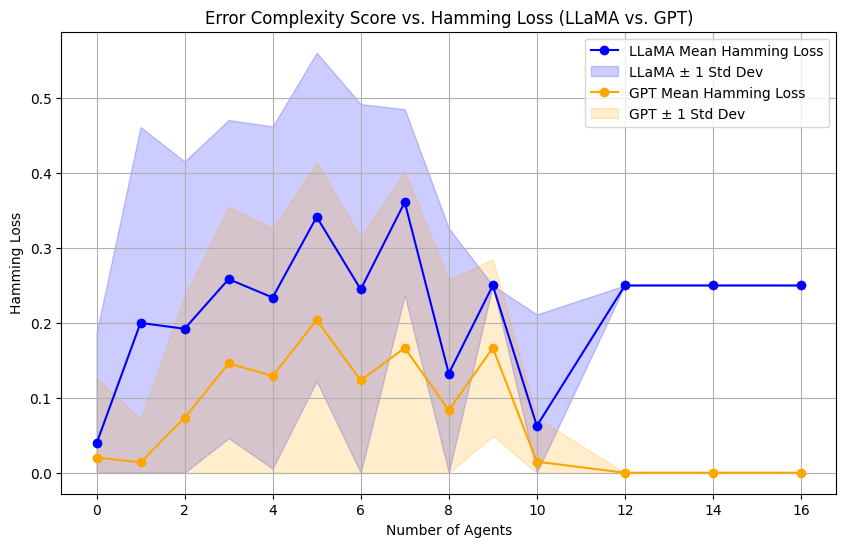

In [ ]:
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import hamming_loss
import numpy as np
import json
import random
from collections import defaultdict

# Load label metadata
with open("original_fixation_transcript_label_missed.json", 'r') as file:
    datalab = json.load(file)

# Load fixation data
with open("original_fixation_transcript_simulated_error_data.json", 'r') as file:
    data = json.load(file)

# Shuffle data for randomness
data = {key: data[key] for key in random.sample(data.keys(), len(data))}

# Load predictions for LLaMA
with open("llama_11b_800_predictions.pkl", "rb") as f:
    llama_predictions = pickle.load(f)

# Load predictions for GPT
with open("data_maarta_final_1025_pred.pkl", "rb") as f:
    gpt_predictions = pickle.load(f)

# Function to count subgraphs
def count_subgraphs(scene_graph):
    return len(scene_graph['scene_graph']['subgraphs'])

# Function to extract binary values for classification
def extract_binary_values(label_dict, sample_id):
    if sample_id not in label_dict:
        return [0, 0, 0, 0]  # Default values
    sample_labels = label_dict[sample_id]
    return [
        sample_labels['Missing Subgraph due to Missing fixation'],
        sample_labels['Missing Subgraph due to reduced fixation duration'],
        sample_labels['Missing Subgraph due to undefined reason'],
        sample_labels['No Missing Subgraph']
    ]

# Function to compute Hamming Loss by complexity score
def compute_hamming_loss_by_complexity(predictions, data, datalab):
    hamming_loss_by_complexity = defaultdict(list)
    for sample_id, sample_data in data.items():
        if sample_id not in predictions or sample_id not in datalab:
            continue  # Skip if data is missing

        # Scene graph for experienced radiologist
        exp_fix = sample_data['correct_data']
        scene_graph_exp = create_scene_graph_by_sentence(exp_fix['transcript'], [
            {'FPOGX': exp_fix['X_ORIGINAL'][i], 'FPOGY': exp_fix['Y_ORIGINAL'][i], 
             'FPOGD': exp_fix['FPOGD'][i], 'Time (in secs)': exp_fix['Time (in secs)'][i]} 
            for i in range(len(exp_fix['X_ORIGINAL']))
        ])

        # Scene graph for inexperienced radiologist
        inexp_fix = sample_data['incorrect_data'] if sample_data['incorrect_data'] else sample_data['correct_data']
        scene_graph_inexp = create_scene_graph_by_sentence(inexp_fix['transcript'], [
            {'FPOGX': inexp_fix['X_ORIGINAL'][i], 'FPOGY': inexp_fix['Y_ORIGINAL'][i], 
             'FPOGD': inexp_fix['FPOGD'][i], 'Time (in secs)': inexp_fix['Time (in secs)'][i]} 
            for i in range(len(inexp_fix['X_ORIGINAL']))
        ])

        # Compute subgraph difference and complexity score
        num_subgraphs_exp = count_subgraphs(scene_graph_exp)
        num_subgraphs_inexp = count_subgraphs(scene_graph_inexp)
        error_complexity_score = abs(num_subgraphs_exp - num_subgraphs_inexp) * num_subgraphs_inexp

        # Extract labels
        predicted_labels = predictions
        actual_labels = new_label_dict  # Replace with ground truth

        # Extract binary values for predicted and actual labels
        predicted_values = extract_binary_values(predicted_labels, sample_id)
        actual_values = extract_binary_values(actual_labels, sample_id)

        # Calculate Hamming Loss for the sample
        sample_hamming_loss = hamming_loss([actual_values], [predicted_values])
        
        # Store Hamming Loss
        hamming_loss_by_complexity[error_complexity_score].append(sample_hamming_loss)
    return hamming_loss_by_complexity

# Compute Hamming Loss for LLaMA
llama_hamming_loss_by_complexity = compute_hamming_loss_by_complexity(llama_predictions, data, datalab)

# Compute Hamming Loss for GPT
gpt_hamming_loss_by_complexity = compute_hamming_loss_by_complexity(gpt_predictions, data, datalab)

# Compute mean and standard deviation for LLaMA
llama_complexity_scores = sorted(llama_hamming_loss_by_complexity.keys())
llama_mean_hamming_loss = [np.mean(llama_hamming_loss_by_complexity[score]) for score in llama_complexity_scores]
llama_std_hamming_loss = [np.std(llama_hamming_loss_by_complexity[score]) for score in llama_complexity_scores]

# Compute mean and standard deviation for GPT
gpt_complexity_scores = sorted(gpt_hamming_loss_by_complexity.keys())
gpt_mean_hamming_loss = [np.mean(gpt_hamming_loss_by_complexity[score]) for score in gpt_complexity_scores]
gpt_std_hamming_loss = [np.std(gpt_hamming_loss_by_complexity[score]) for score in gpt_complexity_scores]

# Plot combined results
plt.figure(figsize=(10, 6))

# Plot LLaMA results
plt.plot(llama_complexity_scores, llama_mean_hamming_loss, label="LLaMA Mean Hamming Loss", marker='o', linestyle='-', color='blue')
llama_lower_bound = np.maximum(np.array(llama_mean_hamming_loss) - np.array(llama_std_hamming_loss), 0)
llama_upper_bound = np.array(llama_mean_hamming_loss) + np.array(llama_std_hamming_loss)
plt.fill_between(llama_complexity_scores, llama_lower_bound, llama_upper_bound, color='blue', alpha=0.2, label="LLaMA ± 1 Std Dev")

# Plot GPT results
plt.plot(gpt_complexity_scores, gpt_mean_hamming_loss, label="GPT Mean Hamming Loss", marker='o', linestyle='-', color='orange')
gpt_lower_bound = np.maximum(np.array(gpt_mean_hamming_loss) - np.array(gpt_std_hamming_loss), 0)
gpt_upper_bound = np.array(gpt_mean_hamming_loss) + np.array(gpt_std_hamming_loss)
plt.fill_between(gpt_complexity_scores, gpt_lower_bound, gpt_upper_bound, color='orange', alpha=0.2, label="GPT ± 1 Std Dev")

# Labels and formatting
plt.xlabel("Number of Agents")
plt.ylabel("Hamming Loss")
plt.title("Error Complexity Score vs. Hamming Loss (LLaMA vs. GPT)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import hamming_loss
import numpy as np
import json
import random
from collections import defaultdict

# Load label metadata
with open("original_fixation_transcript_label_missed.json", 'r') as file:
    datalab = json.load(file)

# Load fixation data
with open("original_fixation_transcript_simulated_error_data.json", 'r') as file:
    data = json.load(file)

# Shuffle data for randomness
data = {key: data[key] for key in random.sample(data.keys(), len(data))}

# Load predictions for LLaMA
with open("llama_11b_800_predictions.pkl", "rb") as f:
    llama_predictions = pickle.load(f)

# Load predictions for GPT
with open("data_maarta_final_1025_pred.pkl", "rb") as f:
    gpt_predictions = pickle.load(f)

# Load predictions for Mistral
with open("mistral_7b_miccai_prediction_1022.pkl", "rb") as f:
    mistral_predictions = pickle.load(f)

# Function to preprocess Mistral predictions
def preprocess_mistral_predictions(predictions):
    processed_predictions = {}
    for sample_id, pred in predictions.items():
        # Replace values greater than 0 with 1, and values less than or equal to 0 with 0
        processed_pred = [1 if x > 0 else 0 for x in pred]
        processed_predictions[sample_id] = processed_pred
    return processed_predictions

# Preprocess Mistral predictions
mistral_predictions = preprocess_mistral_predictions(mistral_predictions)

# Function to count subgraphs
def count_subgraphs(scene_graph):
    return len(scene_graph['scene_graph']['subgraphs'])

# Function to extract binary values for classification
def extract_binary_values(label_dict, sample_id):
    if sample_id not in label_dict:
        return [0, 0, 0, 0]  # Default values
    sample_labels = label_dict[sample_id]
    return [
        sample_labels['Missing Subgraph due to Missing fixation'],
        sample_labels['Missing Subgraph due to reduced fixation duration'],
        sample_labels['Missing Subgraph due to undefined reason'],
        sample_labels['No Missing Subgraph']
    ]

# Function to compute Hamming Loss by complexity score
def compute_hamming_loss_by_complexity(predictions, data, datalab):
    hamming_loss_by_complexity = defaultdict(list)
    for sample_id, sample_data in data.items():
        if sample_id not in predictions or sample_id not in datalab:
            continue  # Skip if data is missing

        # Scene graph for experienced radiologist
        exp_fix = sample_data['correct_data']
        scene_graph_exp = create_scene_graph_by_sentence(exp_fix['transcript'], [
            {'FPOGX': exp_fix['X_ORIGINAL'][i], 'FPOGY': exp_fix['Y_ORIGINAL'][i], 
             'FPOGD': exp_fix['FPOGD'][i], 'Time (in secs)': exp_fix['Time (in secs)'][i]} 
            for i in range(len(exp_fix['X_ORIGINAL']))
        ])

        # Scene graph for inexperienced radiologist
        inexp_fix = sample_data['incorrect_data'] if sample_data['incorrect_data'] else sample_data['correct_data']
        scene_graph_inexp = create_scene_graph_by_sentence(inexp_fix['transcript'], [
            {'FPOGX': inexp_fix['X_ORIGINAL'][i], 'FPOGY': inexp_fix['Y_ORIGINAL'][i], 
             'FPOGD': inexp_fix['FPOGD'][i], 'Time (in secs)': inexp_fix['Time (in secs)'][i]} 
            for i in range(len(inexp_fix['X_ORIGINAL']))
        ])

        # Compute subgraph difference and complexity score
        num_subgraphs_exp = count_subgraphs(scene_graph_exp)
        num_subgraphs_inexp = count_subgraphs(scene_graph_inexp)
        error_complexity_score = abs(num_subgraphs_exp - num_subgraphs_inexp) * num_subgraphs_inexp

        # Extract labels
        predicted_labels = predictions
        actual_labels = new_label_dict  # Replace with ground truth

        # Extract binary values for predicted and actual labels
        predicted_values = extract_binary_values(predicted_labels, sample_id)
        actual_values = extract_binary_values(actual_labels, sample_id)

        # Calculate Hamming Loss for the sample
        sample_hamming_loss = hamming_loss([actual_values], [predicted_values])
        
        # Store Hamming Loss
        hamming_loss_by_complexity[error_complexity_score].append(sample_hamming_loss)
    return hamming_loss_by_complexity

# Compute Hamming Loss for LLaMA
llama_hamming_loss_by_complexity = compute_hamming_loss_by_complexity(llama_predictions, data, datalab)

# Compute Hamming Loss for GPT
gpt_hamming_loss_by_complexity = compute_hamming_loss_by_complexity(gpt_predictions, data, datalab)

# Compute Hamming Loss for Mistral
mistral_hamming_loss_by_complexity = compute_hamming_loss_by_complexity(mistral_predictions, data, datalab)

# Compute mean and standard deviation for LLaMA
llama_complexity_scores = sorted(llama_hamming_loss_by_complexity.keys())
llama_mean_hamming_loss = [np.mean(llama_hamming_loss_by_complexity[score]) for score in llama_complexity_scores]
llama_std_hamming_loss = [np.std(llama_hamming_loss_by_complexity[score]) for score in llama_complexity_scores]

# Compute mean and standard deviation for GPT
gpt_complexity_scores = sorted(gpt_hamming_loss_by_complexity.keys())
gpt_mean_hamming_loss = [np.mean(gpt_hamming_loss_by_complexity[score]) for score in gpt_complexity_scores]
gpt_std_hamming_loss = [np.std(gpt_hamming_loss_by_complexity[score]) for score in gpt_complexity_scores]

# Compute mean and standard deviation for Mistral
mistral_complexity_scores = sorted(mistral_hamming_loss_by_complexity.keys())
mistral_mean_hamming_loss = [np.mean(mistral_hamming_loss_by_complexity[score]) for score in mistral_complexity_scores]
mistral_std_hamming_loss = [np.std(mistral_hamming_loss_by_complexity[score]) for score in mistral_complexity_scores]

# Plot combined results
plt.figure(figsize=(12, 8))

# Plot LLaMA results
plt.plot(llama_complexity_scores, llama_mean_hamming_loss, label="LLaMA Mean Hamming Loss", marker='o', linestyle='-', color='blue')
llama_lower_bound = np.maximum(np.array(llama_mean_hamming_loss) - np.array(llama_std_hamming_loss), 0)
llama_upper_bound = np.array(llama_mean_hamming_loss) + np.array(llama_std_hamming_loss)
plt.fill_between(llama_complexity_scores, llama_lower_bound, llama_upper_bound, color='blue', alpha=0.2, label="LLaMA ± 1 Std Dev")

# Plot GPT results
plt.plot(gpt_complexity_scores, gpt_mean_hamming_loss, label="GPT Mean Hamming Loss", marker='s', linestyle='--', color='orange')
gpt_lower_bound = np.maximum(np.array(gpt_mean_hamming_loss) - np.array(gpt_std_hamming_loss), 0)
gpt_upper_bound = np.array(gpt_mean_hamming_loss) + np.array(gpt_std_hamming_loss)
plt.fill_between(gpt_complexity_scores, gpt_lower_bound, gpt_upper_bound, color='orange', alpha=0.2, label="GPT ± 1 Std Dev")

# Plot Mistral results
plt.plot(mistral_complexity_scores, mistral_mean_hamming_loss, label="Mistral Mean Hamming Loss", marker='^', linestyle='-.', color='green')
mistral_lower_bound = np.maximum(np.array(mistral_mean_hamming_loss) - np.array(mistral_std_hamming_loss), 0)
mistral_upper_bound = np.array(mistral_mean_hamming_loss) + np.array(mistral_std_hamming_loss)
plt.fill_between(mistral_complexity_scores, mistral_lower_bound, mistral_upper_bound, color='green', alpha=0.2, label="Mistral ± 1 Std Dev")

# Labels and formatting
plt.xlabel("Error Complexity Score")
plt.ylabel("Hamming Loss")
plt.title("Error Complexity Score vs. Hamming Loss (LLaMA vs. GPT vs. Mistral)")
plt.legend()
plt.grid(True)
plt.show()

TypeError: '>' not supported between instances of 'str' and 'int'

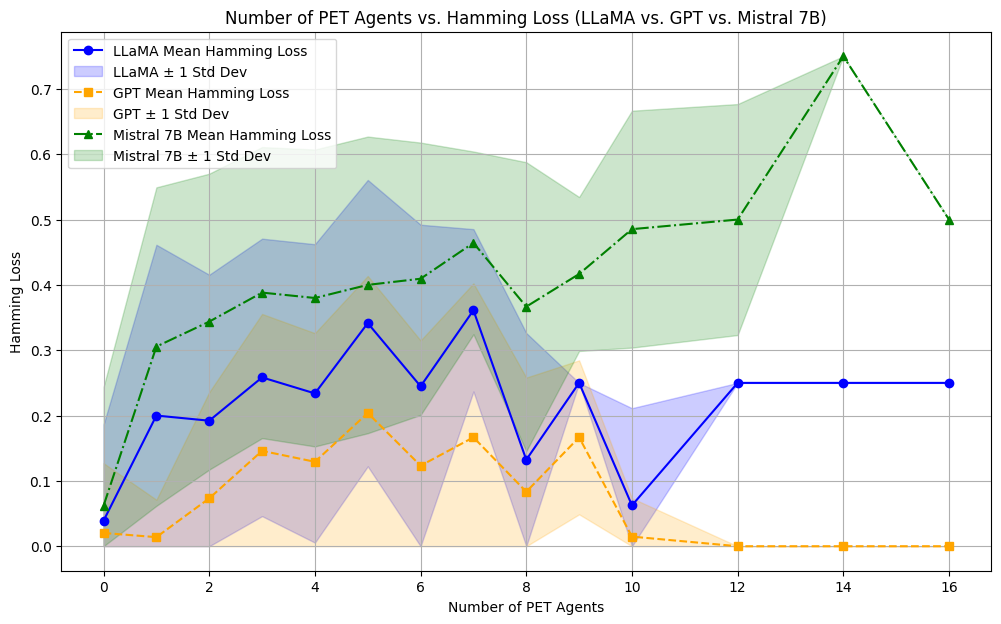

In [ ]:
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import hamming_loss
import numpy as np
import json
import random
from collections import defaultdict

# Load label metadata
with open("original_fixation_transcript_label_missed.json", 'r') as file:
    datalab = json.load(file)

# Load fixation data
with open("original_fixation_transcript_simulated_error_data.json", 'r') as file:
    data = json.load(file)

# Shuffle data for randomness
data = {key: data[key] for key in random.sample(data.keys(), len(data))}

# Load predictions for LLaMA
with open("llama_11b_800_predictions.pkl", "rb") as f:
    llama_predictions = pickle.load(f)

# Load predictions for GPT
with open("data_maarta_final_1025_pred.pkl", "rb") as f:
    gpt_predictions = pickle.load(f)

# Load predictions for Mistral 7B
with open("mistral_7b_miccai_prediction_1022.pkl", "rb") as f:
    mistral_predictions = pickle.load(f)

# Function to count subgraphs
def count_subgraphs(scene_graph):
    return len(scene_graph['scene_graph']['subgraphs'])

# Function to extract binary values for classification
def extract_binary_values(label_dict, sample_id):
    if sample_id not in label_dict:
        return [0, 0, 0, 0]  # Default values
    sample_labels = label_dict[sample_id]
    return [
        sample_labels['Missing Subgraph due to Missing fixation'],
        sample_labels['Missing Subgraph due to reduced fixation duration'],
        sample_labels['Missing Subgraph due to undefined reason'],
        sample_labels['No Missing Subgraph']
    ]

# Function to compute Hamming Loss by complexity score
def compute_hamming_loss_by_complexity(predictions, data, datalab):
    hamming_loss_by_complexity = defaultdict(list)
    for sample_id, sample_data in data.items():
        if sample_id not in predictions or sample_id not in datalab:
            continue  # Skip if data is missing

        # Scene graph for experienced radiologist
        exp_fix = sample_data['correct_data']
        scene_graph_exp = create_scene_graph_by_sentence(exp_fix['transcript'], [
            {'FPOGX': exp_fix['X_ORIGINAL'][i], 'FPOGY': exp_fix['Y_ORIGINAL'][i], 
             'FPOGD': exp_fix['FPOGD'][i], 'Time (in secs)': exp_fix['Time (in secs)'][i]} 
            for i in range(len(exp_fix['X_ORIGINAL']))
        ])

        # Scene graph for inexperienced radiologist
        inexp_fix = sample_data['incorrect_data'] if sample_data['incorrect_data'] else sample_data['correct_data']
        scene_graph_inexp = create_scene_graph_by_sentence(inexp_fix['transcript'], [
            {'FPOGX': inexp_fix['X_ORIGINAL'][i], 'FPOGY': inexp_fix['Y_ORIGINAL'][i], 
             'FPOGD': inexp_fix['FPOGD'][i], 'Time (in secs)': inexp_fix['Time (in secs)'][i]} 
            for i in range(len(inexp_fix['X_ORIGINAL']))
        ])

        # Compute subgraph difference and complexity score
        num_subgraphs_exp = count_subgraphs(scene_graph_exp)
        num_subgraphs_inexp = count_subgraphs(scene_graph_inexp)
        error_complexity_score = abs(num_subgraphs_exp - num_subgraphs_inexp) * num_subgraphs_inexp

        # Extract labels
        predicted_labels = predictions
        actual_labels = new_label_dict  # Replace with ground truth

        # Extract binary values for predicted and actual labels
        predicted_values = extract_binary_values(predicted_labels, sample_id)
        actual_values = extract_binary_values(actual_labels, sample_id)

        # Calculate Hamming Loss for the sample
        sample_hamming_loss = hamming_loss(actual_values, predicted_values)
        
        # Store Hamming Loss
        hamming_loss_by_complexity[error_complexity_score].append(sample_hamming_loss)
    return hamming_loss_by_complexity

# Compute Hamming Loss for LLaMA
llama_hamming_loss_by_complexity = compute_hamming_loss_by_complexity(llama_predictions, data, datalab)

# Compute Hamming Loss for GPT
gpt_hamming_loss_by_complexity = compute_hamming_loss_by_complexity(gpt_predictions, data, datalab)

# Compute Hamming Loss for Mistral 7B
mistral_hamming_loss_by_complexity = compute_hamming_loss_by_complexity(mistral_predictions, data, datalab)

# Compute mean and standard deviation for LLaMA
llama_complexity_scores = sorted(llama_hamming_loss_by_complexity.keys())
llama_mean_hamming_loss = [np.mean(llama_hamming_loss_by_complexity[score]) for score in llama_complexity_scores]
llama_std_hamming_loss = [np.std(llama_hamming_loss_by_complexity[score]) for score in llama_complexity_scores]

# Compute mean and standard deviation for GPT
gpt_complexity_scores = sorted(gpt_hamming_loss_by_complexity.keys())
gpt_mean_hamming_loss = [np.mean(gpt_hamming_loss_by_complexity[score]) for score in gpt_complexity_scores]
gpt_std_hamming_loss = [np.std(gpt_hamming_loss_by_complexity[score]) for score in gpt_complexity_scores]

# Compute mean and standard deviation for Mistral 7B
mistral_complexity_scores = sorted(mistral_hamming_loss_by_complexity.keys())
mistral_mean_hamming_loss = [np.mean(mistral_hamming_loss_by_complexity[score]) for score in mistral_complexity_scores]
mistral_std_hamming_loss = [np.std(mistral_hamming_loss_by_complexity[score]) for score in mistral_complexity_scores]

# Plot combined results
plt.figure(figsize=(12, 7))

# Plot LLaMA results
plt.plot(llama_complexity_scores, llama_mean_hamming_loss, label="LLaMA Mean Hamming Loss", marker='o', linestyle='-', color='blue')
llama_lower_bound = np.maximum(np.array(llama_mean_hamming_loss) - np.array(llama_std_hamming_loss), 0)
llama_upper_bound = np.array(llama_mean_hamming_loss) + np.array(llama_std_hamming_loss)
plt.fill_between(llama_complexity_scores, llama_lower_bound, llama_upper_bound, color='blue', alpha=0.2, label="LLaMA ± 1 Std Dev")

# Plot GPT results
plt.plot(gpt_complexity_scores, gpt_mean_hamming_loss, label="GPT Mean Hamming Loss", marker='s', linestyle='--', color='orange')
gpt_lower_bound = np.maximum(np.array(gpt_mean_hamming_loss) - np.array(gpt_std_hamming_loss), 0)
gpt_upper_bound = np.array(gpt_mean_hamming_loss) + np.array(gpt_std_hamming_loss)
plt.fill_between(gpt_complexity_scores, gpt_lower_bound, gpt_upper_bound, color='orange', alpha=0.2, label="GPT ± 1 Std Dev")

# Plot Mistral 7B results
plt.plot(mistral_complexity_scores, mistral_mean_hamming_loss, label="Mistral 7B Mean Hamming Loss", marker='^', linestyle='-.', color='green')
mistral_lower_bound = np.maximum(np.array(mistral_mean_hamming_loss) - np.array(mistral_std_hamming_loss), 0)
mistral_upper_bound = np.array(mistral_mean_hamming_loss) + np.array(mistral_std_hamming_loss)
plt.fill_between(mistral_complexity_scores, mistral_lower_bound, mistral_upper_bound, color='green', alpha=0.2, label="Mistral 7B ± 1 Std Dev")

# Labels and formatting
plt.xlabel("Number of PET Agents")
plt.ylabel("Hamming Loss")
plt.title("Number of PET Agents vs. Hamming Loss (LLaMA vs. GPT vs. Mistral 7B)")
plt.legend()
plt.grid(True)
plt.show()